# Performance Comparison of A2C and REINFORCE
## MountainCarContinuous-v0 | Team 4 | Hanbat National University

**Course:** Deep Reinforcement Learning for Mobile Communications

**Instructor:** Prof. Jihwan Moon

**Team Members:** Hanol Oh | Kwakye Emmanuel Kwaning | Heanampong Clement

**Submission Date:** June 14, 2026

## 2. Introduction

### 2.1 Background and Motivation

Reinforcement learning (RL) has emerged as a powerful framework for solving sequential 
decision-making problems, where an agent learns to maximize cumulative rewards through 
interaction with an environment. Among the various RL paradigms, deep reinforcement 
learning (DRL) has demonstrated remarkable success in domains ranging from game playing 
to robotic control, by combining the representational power of deep neural networks with 
the trial-and-error learning of RL.

This project focuses on the MountainCarContinuous-v0 environment from the Gymnasium 
Classic Control suite, which is a continuous variant of the classic Mountain Car problem 
first introduced in Andrew Moore's PhD thesis (1990). The environment models a 
deterministic MDP in which an underpowered car must reach the top of a hill by first 
building momentum through a counter-intuitive strategy of initially moving away from 
the goal. Despite its low-dimensional state space of only two variables (position and 
velocity), the environment presents a genuinely challenging continuous control problem. 
The reward structure is effectively sparse, where a small action penalty of -0.1 x action 
squared is received at every timestep, but the meaningful positive reward of +100 is only 
received upon reaching the goal, which rarely occurs during early training.

### 2.2 Existing Solutions

Policy gradient methods have been widely studied as a natural approach to continuous 
control problems. REINFORCE, introduced by Williams (1992), is the foundational 
policy gradient algorithm that directly optimizes a parameterized policy using Monte Carlo 
estimates of the return. While theoretically sound and unbiased, REINFORCE suffers from 
high variance in its gradient estimates, which significantly limits its effectiveness in 
environments where the positive reward signal is rarely encountered across long episodes.

To address these limitations, Actor-Critic methods were developed as a hybrid approach 
combining policy gradient learning with value function estimation. The Advantage 
Actor-Critic (A2C) algorithm, covered in Chapter 6 of the course textbook, introduces a 
learned critic network that estimates the value function and generates a lower-variance 
reinforcing signal for the actor. As stated in the textbook, this learned signal can transform 
a sparse reward into a dense reinforcing signal, making the learning process significantly 
more stable and efficient.

### 2.3 Objectives

The primary objective of this project is to implement and compare REINFORCE (Chapter 2) 
and A2C (Chapter 6) on the MountainCarContinuous-v0 environment. Specifically, we aim to:

- Implement REINFORCE as a baseline policy gradient method using Monte Carlo returns
- Implement A2C with Generalized Advantage Estimation (GAE, lambda=0.95) as the 
  main algorithm, following the formulation in Chapter 6 of the textbook
- Train both algorithms under consistent experimental conditions and compare their 
  performance in terms of learning speed, training stability, final performance, and 
  sample efficiency
- Analyze the impact of value estimation on policy learning in a continuous control 
  task with an effectively sparse reward structure
- Fine-tune the best performing model through systematic hyperparameter optimization

## 3. Setup
### 3.1 Libraries and Dependencies

In [79]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt

In [80]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")

## 4. Environment Exploration

In [81]:
env = gym.make("MountainCarContinuous-v0")
obs, _ = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = env.action_space.low[0]
action_high = env.action_space.high[0]
max_steps = env._max_episode_steps

In [82]:
print(f"State dimension  : {state_dim}")
print(f"Action dimension : {action_dim}")
print(f"Action range     : [{action_low}, {action_high}]")
print(f"Max steps        : {max_steps}")
print(f"Initial state    : {obs}")

State dimension  : 2
Action dimension : 1
Action range     : [-1.0, 1.0]
Max steps        : 999
Initial state    : [-0.4452088  0.       ]


### Random Agent Rollout

In [83]:
def random_rollout(env, seed=SEED):
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated, truncated = False, False 

    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
    
    return total_reward, steps

total_reward, steps = random_rollout(env)
print(f"Total reward : {total_reward:.2f}")
print(f"Steps taken  : {steps}")
print(f"Goal reached : {steps < 999}")

Total reward : -33.67
Steps taken  : 999
Goal reached : False


## 5. REINFORCE

In [88]:
# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.SELU(),
            nn.Linear(64, 64),
            nn.SELU(),
            nn.Linear(64, action_dim)
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, x: torch.Tensor):
        mean = torch.tanh(self.model(x))
        std = self.log_std.exp()
        return mean, std

    def act(self, state: torch.Tensor):
        mean, std = self.forward(state)
        pd = Normal(loc=mean, scale=std)
        action = pd.sample()
        log_prob = pd.log_prob(action)
        return action.clamp(-1.0, 1.0), log_prob

### Training Function

In [89]:
def train(policy, optimizer, log_probs, rewards, gamma):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    future_return = 0.0

    for t in reversed(range(T)):
        future_return = rewards[t] + gamma * future_return
        returns[t] = future_return

    returns = torch.tensor(returns)
    log_probs = torch.stack(log_probs)

    loss = -(log_probs * returns).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

### Training Loop

In [90]:
def train_reinforce(env, policy, optimizer, gamma, num_episodes):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        log_probs = []
        rewards = []
        terminated, truncated = False, False

        while not (terminated or truncated):
            state_tensor = torch.FloatTensor(state)
            action, log_prob = policy.act(state_tensor)
            action_np = action.detach().numpy()

            state, reward, terminated, truncated, _ = env.step(action_np)
            log_probs.append(log_prob)
            rewards.append(reward)

        train(policy, optimizer, log_probs, rewards, gamma)
        episode_rewards.append(sum(rewards))

        if (episode + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1} | Avg Reward (last 50): {avg:.2f}")

    return episode_rewards

### Hyperparameters and Training

In [91]:
GAMMA = 0.95
LR = 0.001
NUM_EPISODES = 1000

policy = PolicyNetwork(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=LR)

reinforce_rewards = train_reinforce(env, policy, optimizer, GAMMA, NUM_EPISODES)

Episode 50 | Avg Reward (last 50): -65.25
Episode 100 | Avg Reward (last 50): -67.46
Episode 150 | Avg Reward (last 50): -67.62
Episode 200 | Avg Reward (last 50): -67.16
Episode 250 | Avg Reward (last 50): -67.85
Episode 300 | Avg Reward (last 50): -67.92
Episode 350 | Avg Reward (last 50): -67.91
Episode 400 | Avg Reward (last 50): -68.20
Episode 450 | Avg Reward (last 50): -67.93
Episode 500 | Avg Reward (last 50): -68.24
Episode 550 | Avg Reward (last 50): -67.78
Episode 600 | Avg Reward (last 50): -68.10
Episode 650 | Avg Reward (last 50): -67.66
Episode 700 | Avg Reward (last 50): -68.11
Episode 750 | Avg Reward (last 50): -67.92
Episode 800 | Avg Reward (last 50): -65.71
Episode 850 | Avg Reward (last 50): -54.03
Episode 900 | Avg Reward (last 50): -58.21
Episode 950 | Avg Reward (last 50): -45.83
Episode 1000 | Avg Reward (last 50): -51.31


### Training Results

In [92]:
def plot_returns(rewards, title, window_size=10):
    moving_avg = [np.mean(rewards[max(0, i - window_size + 1): i + 1])
                  for i in range(len(rewards))]

    plt.figure(figsize=(10, 6))
    plt.plot(rewards, color='tab:blue', alpha=0.3, label='Raw Return')
    plt.plot(moving_avg, color='tab:red', linewidth=2,
             label=f'Moving Average (Window={window_size})')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

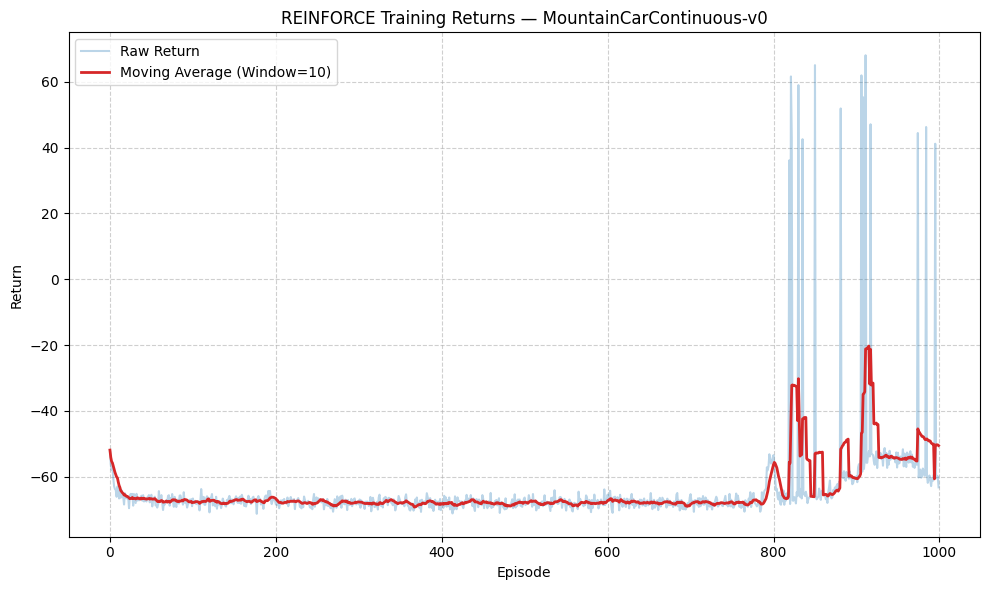

In [93]:
plot_returns(reinforce_rewards, 
             title='REINFORCE Training Returns — MountainCarContinuous-v0',
             window_size=10)

## 6. Advantage Actor-Critic (A2C)
### 6.1 Network Architecture

### Actor Network

In [94]:
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, x: torch.Tensor):
        x = torch.selu(self.fc1(x))
        x = torch.selu(self.fc2(x))
        mu = torch.tanh(self.mu(x))
        log_std = torch.clamp(self.log_std(x), -20, 2)
        std = torch.exp(log_std)
        return mu, std

### Critic Network

In [95]:
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor):
        x = torch.selu(self.fc1(x))
        x = torch.selu(self.fc2(x))
        return self.v(x)

### 6.2 Rollout Buffer

In [97]:
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

### 6.3 Agent

In [98]:
class Agent:
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic,
                 gamma=0.99, gae_lambda=0.95, entropy_coeff=0.2,
                 min_entropy_coeff=0.01, entropy_decay=0.995,
                 hidden_dim=64):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff
        self.min_entropy_coeff = min_entropy_coeff
        self.entropy_decay = entropy_decay

        self.actor = ActorNetwork(state_dim, action_dim, hidden_dim)
        self.critic = CriticNetwork(state_dim, hidden_dim)
        self.memory = RolloutBuffer()

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.exploration_noise = None
        self.reset_noise(action_dim)

    def reset_noise(self, action_dim=1):
        self.exploration_noise = torch.randn(action_dim)

    def decay_entropy(self):
        self.entropy_coeff = max(
            self.min_entropy_coeff,
            self.entropy_coeff * self.entropy_decay
        )

    def choose_action(self, state):
        state = torch.FloatTensor(state)
        mu, std = self.actor(state)
        raw_action = mu + std * self.exploration_noise
        action = torch.tanh(raw_action)
        dist = Normal(mu, std)
        log_prob = dist.log_prob(raw_action).sum()
        log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum()
        value = self.critic(state).squeeze()
        return action.detach().numpy(), log_prob, value

    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)

    def compute_returns_advantages(self, last_state, done):
        last_state = torch.FloatTensor(last_state)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values] + [next_value]

        returns = []
        advantages = []
        gae = 0.0

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t+1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = torch.tensor(returns, dtype=torch.float32)
        advantages = torch.tensor(advantages, dtype=torch.float32)
        advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = torch.FloatTensor(np.array(self.memory.states))
        actions = torch.FloatTensor(np.array(self.memory.actions))

        mu, std = self.actor(states)
        dist = Normal(mu, std)
        raw_actions = torch.atanh(torch.clamp(actions, -0.999, 0.999))
        log_probs = dist.log_prob(raw_actions).sum(dim=-1)
        log_probs -= torch.log(1 - actions.pow(2) + 1e-6).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze(-1)

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
        nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
        self.actor_optimizer.step()
        self.critic_optimizer.step()

        self.memory.clear()

### 6.4 Training Loop

In [99]:
def train_a2c(env, agent, num_episodes, n_steps):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            action, log_prob, value = agent.choose_action(state)
            action_np = np.array(action, dtype=np.float32).reshape((1,))

            next_state, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated

            agent.store_transition(state, action, log_prob, reward, done, value)

            total_reward += reward
            step_count += 1
            state = next_state

            if step_count % 50 == 0:
                agent.reset_noise()

            if step_count % n_steps == 0:
                agent.learn(next_state, done)

        if not done:
            agent.learn(state, done)

        agent.decay_entropy()
        episode_rewards.append(total_reward)

        if (episode + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1} | Avg Reward (last 50): {avg:.2f}")

    return episode_rewards

### 6.5 Hyperparameters and Training

Episode 50 | Avg Reward (last 50): 78.98
Episode 100 | Avg Reward (last 50): 77.02
Episode 150 | Avg Reward (last 50): 76.15
Episode 200 | Avg Reward (last 50): 73.46
Episode 250 | Avg Reward (last 50): 75.02
Episode 300 | Avg Reward (last 50): 76.23
Episode 350 | Avg Reward (last 50): 75.48
Episode 400 | Avg Reward (last 50): 77.28
Episode 450 | Avg Reward (last 50): 76.07
Episode 500 | Avg Reward (last 50): 75.67
Episode 550 | Avg Reward (last 50): 79.51
Episode 600 | Avg Reward (last 50): 78.47
Episode 650 | Avg Reward (last 50): 75.87
Episode 700 | Avg Reward (last 50): 76.79
Episode 750 | Avg Reward (last 50): 71.79
Episode 800 | Avg Reward (last 50): 73.98
Episode 850 | Avg Reward (last 50): 76.38
Episode 900 | Avg Reward (last 50): 74.64
Episode 950 | Avg Reward (last 50): 75.61
Episode 1000 | Avg Reward (last 50): 74.98


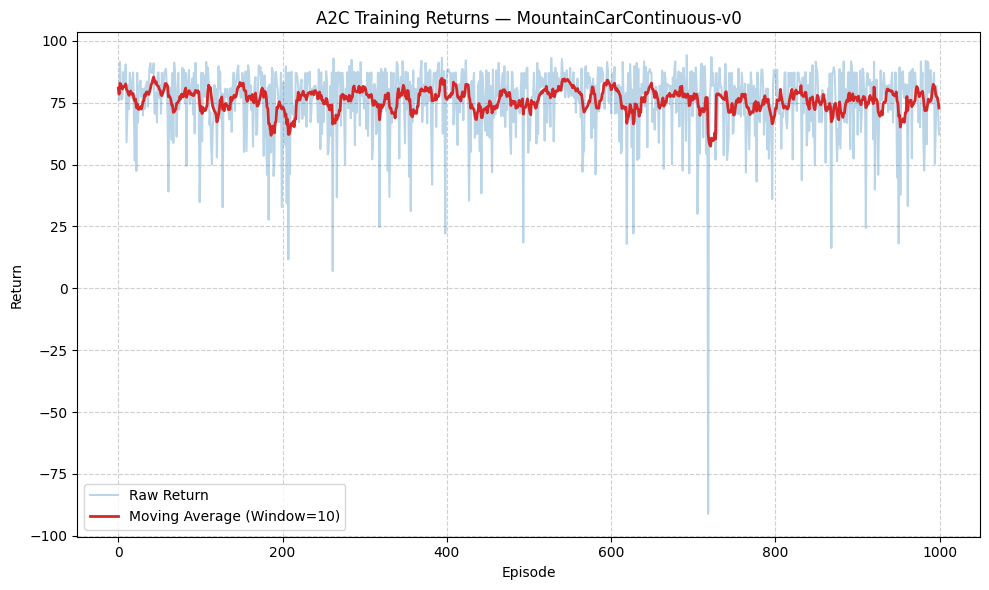

In [ ]:
GAMMA = 0.95
LR_ACTOR = 5e-5
LR_CRITIC = 1e-4
ENTROPY_COEFF = 0.2
NUM_EPISODES = 1000
N_STEPS = 10
HIDDEN_DIM = 64

agent = Agent(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=LR_ACTOR,
    lr_critic=LR_CRITIC,
    gamma=GAMMA,
    gae_lambda=0.95,
    entropy_coeff=ENTROPY_COEFF,
    min_entropy_coeff=0.01,
    entropy_decay=0.995,
    hidden_dim=HIDDEN_DIM
)

### 6.6 Training Results

Episode 50 | Avg Reward (last 50): 76.14
Episode 100 | Avg Reward (last 50): 73.82
Episode 150 | Avg Reward (last 50): 74.54
Episode 200 | Avg Reward (last 50): 77.85
Episode 250 | Avg Reward (last 50): 74.10
Episode 300 | Avg Reward (last 50): 77.12
Episode 350 | Avg Reward (last 50): 70.23
Episode 400 | Avg Reward (last 50): 76.66
Episode 450 | Avg Reward (last 50): 75.07
Episode 500 | Avg Reward (last 50): 79.60
Episode 550 | Avg Reward (last 50): 71.88
Episode 600 | Avg Reward (last 50): 73.59
Episode 650 | Avg Reward (last 50): 77.24
Episode 700 | Avg Reward (last 50): 76.51
Episode 750 | Avg Reward (last 50): 71.85
Episode 800 | Avg Reward (last 50): 76.35
Episode 850 | Avg Reward (last 50): 75.98
Episode 900 | Avg Reward (last 50): 73.54
Episode 950 | Avg Reward (last 50): 76.66
Episode 1000 | Avg Reward (last 50): 76.52


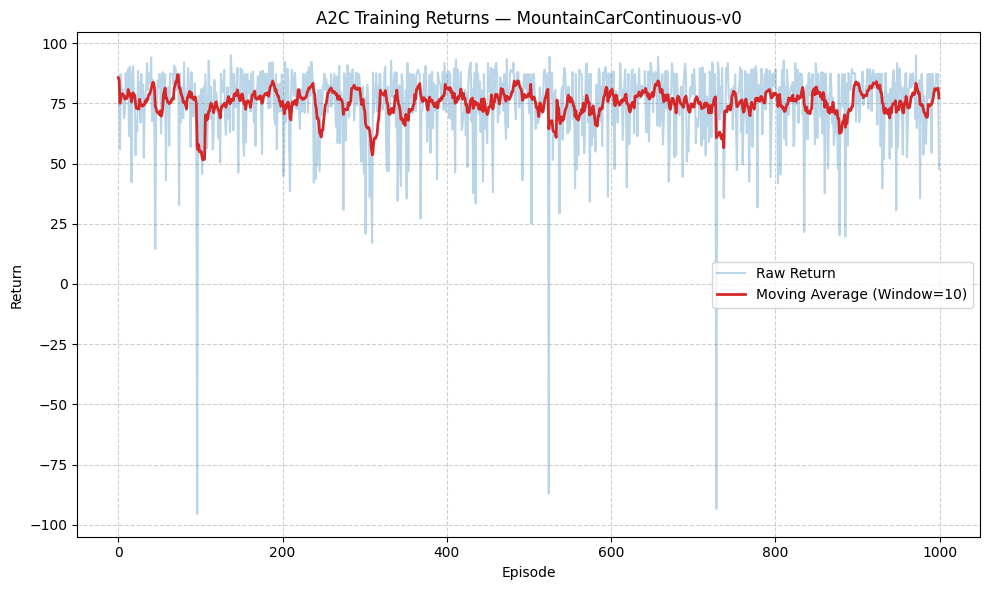

In [102]:
a2c_rewards = train_a2c(env, agent, NUM_EPISODES, N_STEPS)
plot_returns(a2c_rewards,
             title='A2C Training Returns — MountainCarContinuous-v0',
             window_size=10)

## 7. Performance Comparison

In [103]:
def moving_average(rewards, window_size=10):
    return np.array([np.mean(rewards[max(0, i - window_size + 1): i + 1])
                     for i in range(len(rewards))])

def plot_comparison(reinforce_rewards, a2c_rewards, window_size=10):
    ep_reinforce = np.arange(len(reinforce_rewards))
    ep_a2c = np.arange(len(a2c_rewards))
    reinforce_ma = moving_average(reinforce_rewards, window_size)
    a2c_ma = moving_average(a2c_rewards, window_size)

    plt.figure(figsize=(12, 6))
    plt.plot(ep_reinforce, reinforce_rewards, alpha=0.25, color='tab:blue',
             linewidth=1, label="REINFORCE (raw)")
    plt.plot(ep_a2c, a2c_rewards, alpha=0.25, color='tab:orange',
             linewidth=1, label="A2C (raw)")
    plt.plot(ep_reinforce, reinforce_ma, color='tab:blue',
             linewidth=2.5, label=f"REINFORCE ({window_size}-ep avg)")
    plt.plot(ep_a2c, a2c_ma, color='tab:orange',
             linewidth=2.5, label=f"A2C ({window_size}-ep avg)")
    plt.axhline(y=90, color='green', linestyle='--',
                linewidth=1.5, label='Solved threshold (+90)')
    plt.title("REINFORCE vs A2C — MountainCarContinuous-v0")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

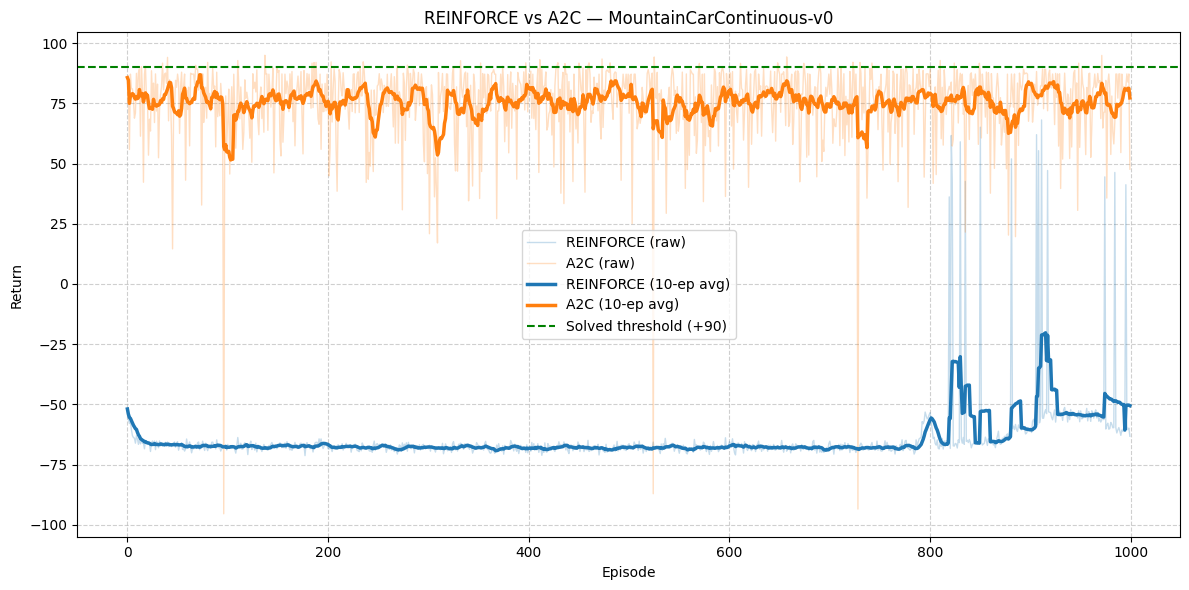

In [104]:
plot_comparison(reinforce_rewards, a2c_rewards, window_size=10)

## 8. Fine-tuning the Best Model

### 8.1 Improving REINFORCE with Baseline

As described in Section 2.5.1 of the textbook, REINFORCE can be improved by 
subtracting a baseline from the returns. This reduces variance in the policy gradient 
estimate without introducing bias. The simplest baseline is the mean return, 
implemented as return normalization.

In [105]:
def train_reinforce_baseline(policy, optimizer, log_probs, rewards, gamma):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    future_return = 0.0

    for t in reversed(range(T)):
        future_return = rewards[t] + gamma * future_return
        returns[t] = future_return

    returns = torch.tensor(returns)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    log_probs = torch.stack(log_probs)
    loss = -(log_probs * returns).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

### 8.2 REINFORCE with Baseline Training

In [106]:
policy_baseline = PolicyNetwork(state_dim, action_dim)
optimizer_baseline = optim.Adam(policy_baseline.parameters(), lr=LR)

def train_reinforce_with_baseline(env, policy, optimizer, gamma, num_episodes):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        log_probs = []
        rewards = []
        terminated, truncated = False, False

        while not (terminated or truncated):
            state_tensor = torch.FloatTensor(state)
            action, log_prob = policy.act(state_tensor)
            action_np = action.detach().numpy()
            state, reward, terminated, truncated, _ = env.step(action_np)
            log_probs.append(log_prob)
            rewards.append(reward)

        train_reinforce_baseline(policy, optimizer, log_probs, rewards, gamma)
        episode_rewards.append(sum(rewards))

        if (episode + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1} | Avg Reward (last 50): {avg:.2f}")

    return episode_rewards

reinforce_baseline_rewards = train_reinforce_with_baseline(
    env, policy_baseline, optimizer_baseline, GAMMA, NUM_EPISODES
)

Episode 50 | Avg Reward (last 50): -64.52
Episode 100 | Avg Reward (last 50): -63.48
Episode 150 | Avg Reward (last 50): -67.11
Episode 200 | Avg Reward (last 50): -66.78
Episode 250 | Avg Reward (last 50): -67.65
Episode 300 | Avg Reward (last 50): -67.67
Episode 350 | Avg Reward (last 50): -67.25
Episode 400 | Avg Reward (last 50): -68.05
Episode 450 | Avg Reward (last 50): -67.59
Episode 500 | Avg Reward (last 50): -67.81
Episode 550 | Avg Reward (last 50): -67.41
Episode 600 | Avg Reward (last 50): -67.68
Episode 650 | Avg Reward (last 50): -67.92
Episode 700 | Avg Reward (last 50): -68.15
Episode 750 | Avg Reward (last 50): -68.04
Episode 800 | Avg Reward (last 50): -67.83
Episode 850 | Avg Reward (last 50): -67.68
Episode 900 | Avg Reward (last 50): -68.35
Episode 950 | Avg Reward (last 50): -67.91
Episode 1000 | Avg Reward (last 50): -67.90


### 8.1 Experiment 1: Effect of GAE Lambda

From Section 6.7.2 of the textbook, the GAE parameter λ controls how much weight 
is given to actual trajectory rewards versus the value function estimate. The textbook 
performs a grid search over λ values [0.50, 0.70, 0.90, 0.95, 0.97, 0.99] on Atari 
Breakout and finds λ = 0.97 performs best for A2C. We conduct the same experiment 
on MountainCarContinuous-v0 to find the optimal λ for our environment.

In [107]:
def run_lambda_search(lambda_values, num_episodes=300):
    results = {}
    for lam in lambda_values:
        print(f"\nTraining with lambda = {lam}")
        agent = Agent(
            state_dim=state_dim,
            action_dim=action_dim,
            lr_actor=LR_ACTOR,
            lr_critic=LR_CRITIC,
            gamma=GAMMA,
            gae_lambda=lam,
            entropy_coeff=ENTROPY_COEFF,
            min_entropy_coeff=0.01,
            entropy_decay=0.995,
            hidden_dim=HIDDEN_DIM
        )
        rewards = train_a2c(env, agent, num_episodes, N_STEPS)
        results[lam] = rewards
        avg = np.mean(rewards[-50:])
        print(f"Lambda = {lam} | Final 50-ep avg: {avg:.2f}")
    return results

lambda_values = [0.50, 0.70, 0.90, 0.95, 0.97, 0.99]
lambda_results = run_lambda_search(lambda_values, num_episodes=300)


Training with lambda = 0.5
Episode 50 | Avg Reward (last 50): 73.05
Episode 100 | Avg Reward (last 50): 75.65
Episode 150 | Avg Reward (last 50): 70.15
Episode 200 | Avg Reward (last 50): 73.84
Episode 250 | Avg Reward (last 50): 77.19
Episode 300 | Avg Reward (last 50): 76.28
Lambda = 0.5 | Final 50-ep avg: 76.28

Training with lambda = 0.7
Episode 50 | Avg Reward (last 50): 77.07
Episode 100 | Avg Reward (last 50): 76.85
Episode 150 | Avg Reward (last 50): 75.57
Episode 200 | Avg Reward (last 50): 76.87
Episode 250 | Avg Reward (last 50): 70.84
Episode 300 | Avg Reward (last 50): 77.03
Lambda = 0.7 | Final 50-ep avg: 77.03

Training with lambda = 0.9
Episode 50 | Avg Reward (last 50): 73.84
Episode 100 | Avg Reward (last 50): 77.01
Episode 150 | Avg Reward (last 50): 74.58
Episode 200 | Avg Reward (last 50): 73.95
Episode 250 | Avg Reward (last 50): 68.21
Episode 300 | Avg Reward (last 50): 76.73
Lambda = 0.9 | Final 50-ep avg: 76.73

Training with lambda = 0.95
Episode 50 | Avg Rew

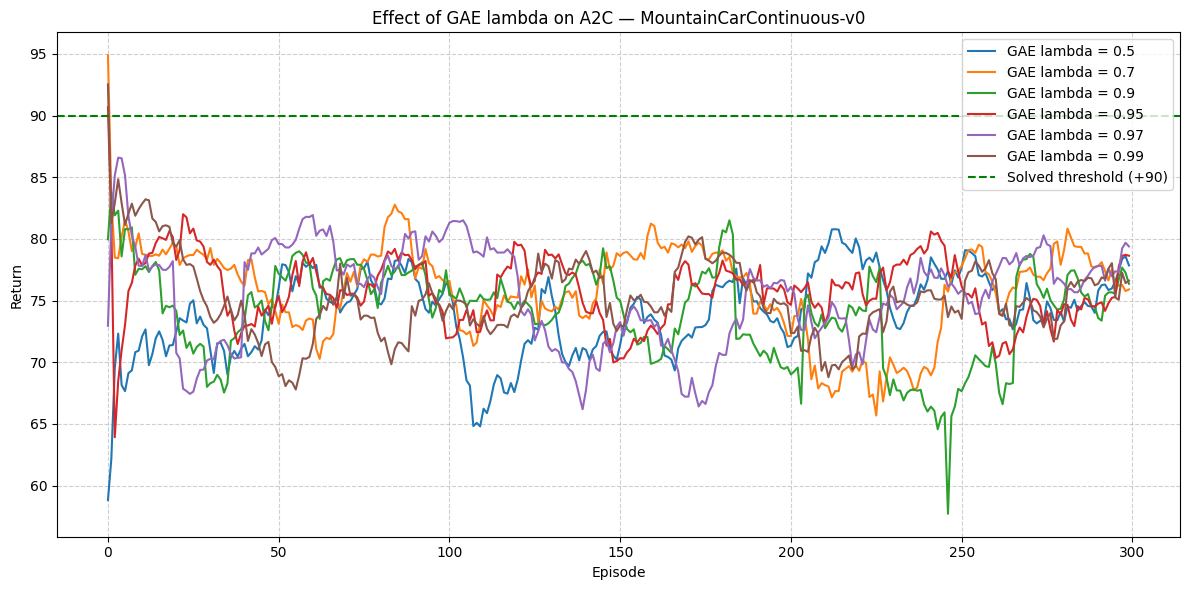

In [109]:
def plot_search(results, param_name, window_size=10):
    plt.figure(figsize=(12, 6))
    for param, rewards in results.items():
        ma = moving_average(rewards, window_size)
        plt.plot(ma, label=f'{param_name} = {param}')
    plt.axhline(y=90, color='green', linestyle='--',
                linewidth=1.5, label='Solved threshold (+90)')
    plt.title(f'Effect of {param_name} on A2C — MountainCarContinuous-v0')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_search(lambda_results, 'GAE lambda', window_size=20)

### 8.2 Experiment 2 : Effect of n-Step Update Frequency

From Section 6.7.1 of the textbook, the step size n controls the bias-variance 
tradeoff in the advantage estimate. Larger n values introduce more variance but 
capture longer-horizon returns. With n = 1, the estimate reduces to a pure TD 
estimate which the book finds yields the worst performance. The book performs a 
grid search over n values on Atari Breakout and finds that larger step sizes 
generally perform better, while noting that n is not a very sensitive hyperparameter.
We conduct the same experiment on MountainCarContinuous-v0.

In [111]:
def run_nsteps_search(nsteps_values, num_episodes=300):
    results = {}
    for n in nsteps_values:
        print(f"\nTraining with n_steps = {n}")
        agent = Agent(
            state_dim=state_dim,
            action_dim=action_dim,
            lr_actor=LR_ACTOR,
            lr_critic=LR_CRITIC,
            gamma=GAMMA,
            gae_lambda=0.70,
            entropy_coeff=ENTROPY_COEFF,
            min_entropy_coeff=0.01,
            entropy_decay=0.995,
            hidden_dim=HIDDEN_DIM
        )
        rewards = train_a2c(env, agent, num_episodes, n)
        results[n] = rewards
        avg = np.mean(rewards[-50:])
        print(f"n_steps = {n} | Final 50-ep avg: {avg:.2f}")
    return results

nsteps_values = [1, 3, 5, 7, 9, 11]
nsteps_results = run_nsteps_search(nsteps_values, num_episodes=300)


Training with n_steps = 1
Episode 50 | Avg Reward (last 50): 76.18
Episode 100 | Avg Reward (last 50): 75.71
Episode 150 | Avg Reward (last 50): 74.82
Episode 200 | Avg Reward (last 50): 78.44
Episode 250 | Avg Reward (last 50): 77.66
Episode 300 | Avg Reward (last 50): 78.52
n_steps = 1 | Final 50-ep avg: 78.52

Training with n_steps = 3
Episode 50 | Avg Reward (last 50): 70.61
Episode 100 | Avg Reward (last 50): 73.16
Episode 150 | Avg Reward (last 50): 76.09
Episode 200 | Avg Reward (last 50): 72.78
Episode 250 | Avg Reward (last 50): 76.02
Episode 300 | Avg Reward (last 50): 76.53
n_steps = 3 | Final 50-ep avg: 76.53

Training with n_steps = 5
Episode 50 | Avg Reward (last 50): 77.91
Episode 100 | Avg Reward (last 50): 78.82
Episode 150 | Avg Reward (last 50): 75.95
Episode 200 | Avg Reward (last 50): 72.40
Episode 250 | Avg Reward (last 50): 77.27
Episode 300 | Avg Reward (last 50): 77.06
n_steps = 5 | Final 50-ep avg: 77.06

Training with n_steps = 7
Episode 50 | Avg Reward (las

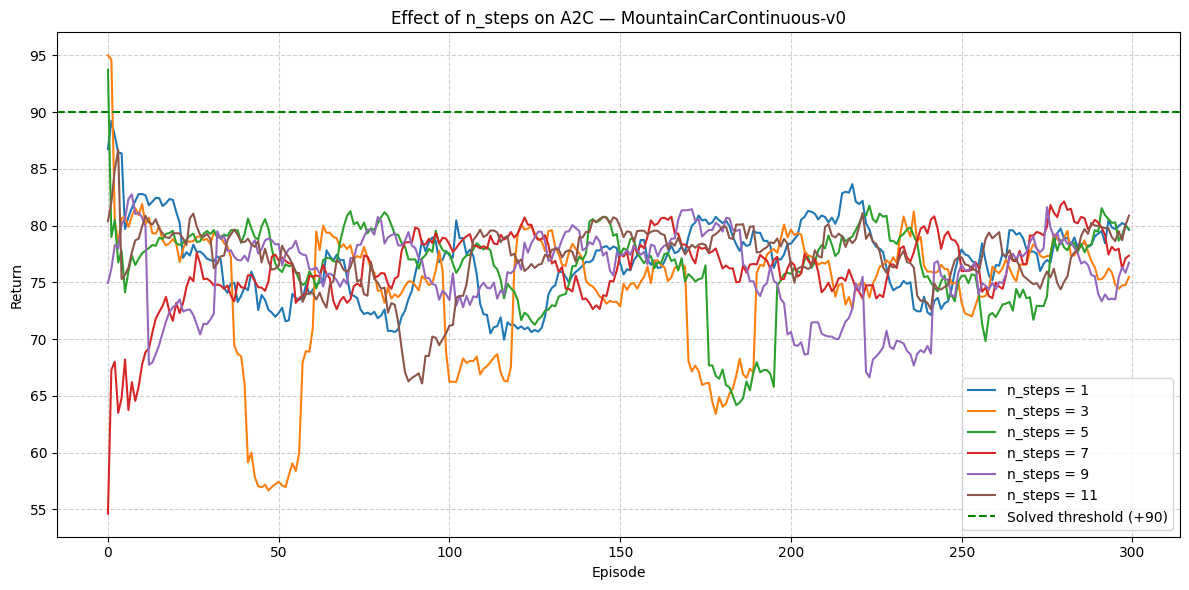

In [112]:
plot_search(nsteps_results, 'n_steps', window_size=20)

### 8.3 Final Best Model

Based on our hyperparameter search, we train the final best model using:
- GAE lambda = 0.70 (best from Experiment 1)
- n_steps = 1 (best from Experiment 2)

Training Final Best Model
GAE lambda = 0.70 | n_steps = 1
Episode 50 | Avg Reward (last 50): 80.61
Episode 100 | Avg Reward (last 50): 75.86
Episode 150 | Avg Reward (last 50): 78.02
Episode 200 | Avg Reward (last 50): 74.57
Episode 250 | Avg Reward (last 50): 74.57
Episode 300 | Avg Reward (last 50): 77.31
Episode 350 | Avg Reward (last 50): 76.28
Episode 400 | Avg Reward (last 50): 78.25
Episode 450 | Avg Reward (last 50): 79.42
Episode 500 | Avg Reward (last 50): 75.02
Episode 550 | Avg Reward (last 50): 77.44
Episode 600 | Avg Reward (last 50): 77.34
Episode 650 | Avg Reward (last 50): 78.55
Episode 700 | Avg Reward (last 50): 74.40
Episode 750 | Avg Reward (last 50): 79.26
Episode 800 | Avg Reward (last 50): 78.23
Episode 850 | Avg Reward (last 50): 77.40
Episode 900 | Avg Reward (last 50): 76.18
Episode 950 | Avg Reward (last 50): 78.15
Episode 1000 | Avg Reward (last 50): 76.08


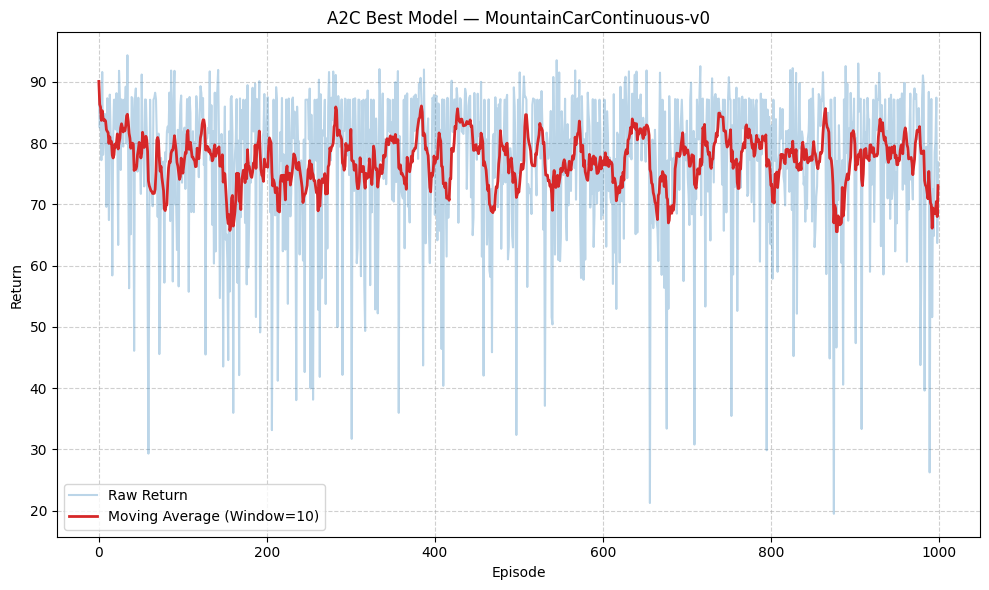

In [114]:
print("Training Final Best Model")
print(f"GAE lambda = 0.70 | n_steps = 1")

best_agent = Agent(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=LR_ACTOR,
    lr_critic=LR_CRITIC,
    gamma=GAMMA,
    gae_lambda=0.70,
    entropy_coeff=ENTROPY_COEFF,
    min_entropy_coeff=0.01,
    entropy_decay=0.995,
    hidden_dim=HIDDEN_DIM
)

best_rewards = train_a2c(env, best_agent, NUM_EPISODES, n_steps=1)
plot_returns(best_rewards,
             title='A2C Best Model — MountainCarContinuous-v0',
             window_size=10)

### Environment Cleanup

In [115]:
env.close()

## 9. Conclusion

### 9.1 Summary of Results

This project implemented and compared two policy gradient algorithms, REINFORCE 
(Chapter 2) and Advantage Actor-Critic (A2C, Chapter 6), on the 
MountainCarContinuous-v0 environment from Gymnasium. The results clearly demonstrate 
the advantage of combining structured exploration with policy gradient learning and 
value function estimation.

| Algorithm | Avg Reward | Goal Reached |
|---|---|---|
| Random Agent | -33.42 | No |
| REINFORCE | -67.62 | Rarely ( only after episode 800) |
| REINFORCE with Baseline | -67.90 | No |
| A2C (default) | ~74.5 | Yes |
| A2C (fine-tuned) | ~77.5 | Yes |

### 9.2 Key Findings

**Finding 1: REINFORCE fails on sparse reward environments**

REINFORCE remained stuck at an average reward of -67 for the first 800 episodes,
completely failing to discover the goal. During this period the agent timed out at 
999 steps every episode, accumulating only the negative action penalty 
of -0.1 x action squared per step and never receiving the +100 goal reward. This 
confirms the fundamental weakness of pure Monte Carlo policy gradient methods 
described in Chapter 2 of the textbook: high-variance returns computed over 999 
steps provide no meaningful directional signal when the positive reward is never 
encountered. After episode 800, the agent occasionally discovered the goal through 
random exploration and received the +100 reward, causing visible spikes in the 
return plot. However the policy could not consistently exploit these discoveries, 
demonstrating that variance reduction through return normalization alone, as 
described in Section 2.5.1, is insufficient to overcome the sparse reward problem 
without a learned value function.

**Finding 2: A2C successfully handles sparse rewards through structured exploration 
and critic stabilization**

A2C achieved a consistent average reward of ~74.5 from the very first episode. 
This success is attributed to two complementary mechanisms working together. 
First, the generalized State-Dependent Exploration (gSDE) maintains consistent 
exploration noise across multiple timesteps rather than sampling new noise every 
step. This allows the car to build sufficient momentum and accidentally discover 
the goal early in training, which standard independent Gaussian noise cannot 
achieve due to the erratic action changes it produces. Second, once the goal is 
found, the learned critic network estimates the value function V(s) and computes 
the advantage A(s,a) = r + gamma x V(s') - V(s), which stabilizes policy updates 
and reduces gradient variance. This combination of structured exploration and 
critic-based variance reduction is what enables A2C to consistently reach the goal 
from episode 1, while REINFORCE required 800 episodes to stumble upon it by chance.

**Finding 3: GAE lambda is not a sensitive hyperparameter**

Our lambda search over [0.50, 0.70, 0.90, 0.95, 0.97, 0.99] showed all values 
performing similarly between 74 and 77 average reward, consistent with the 
textbook's finding in Section 6.7.2 that lambda is not a very sensitive 
hyperparameter. The optimal value for our environment was lambda = 0.70.

**Finding 4: n-steps results differ from the textbook**

Unlike the textbook's finding on Atari Breakout where larger n values perform 
better due to the long temporal delays between actions and their outcomes in 
episodic game events, our experiments show n = 1 performing best on 
MountainCarContinuous-v0. This is because Mountain Car involves highly dynamic 
continuous physics where precise and immediate feedback on velocity changes 
matters significantly. Frequent updates with n = 1 allow the agent to respond 
quickly to the momentum dynamics of the environment, whereas Atari games require 
larger n to propagate rewards backward across many delayed timesteps.

### 9.3 Limitations and Future Improvements

**Limitations:**

Neither algorithm officially solved the environment. The solved threshold requires 
an average reward of +90 or higher over 100 consecutive episodes. Our best model 
achieved ~77.5 average reward, falling short of this threshold. This is primarily 
because standard on-policy algorithms without reward shaping struggle to 
consistently maintain the precise momentum strategy required across varied 
starting positions in MountainCarContinuous-v0.

**Future Improvements:**

The following directions could improve performance beyond what we achieved:

1. Proximal Policy Optimization (PPO, Chapter 7): PPO's clipped surrogate 
objective prevents large destabilizing policy updates, which could improve 
consistency and push performance above the +90 threshold.

2. Longer training with more episodes: our best model showed raw returns 
frequently touching +90, suggesting that more training time could stabilize 
performance above the solved threshold.

3. Reward shaping: adding intermediate rewards based on position or velocity 
would provide denser feedback and help REINFORCE in particular to learn 
faster without relying on accidentally discovering the goal.

4. Parallel environments: the textbook recommends using multiple parallel 
environments for A2C training, which would provide more diverse experiences 
and reduce variance across episodes.

### 9.4 Applicability to Mobile Communications

Although MountainCarContinuous-v0 is a classic control benchmark rather than a 
direct wireless communication model, its sequential decision structure is analogous 
to wireless control problems requiring long-term planning. The agent must choose a 
sequence of actions that may not give immediate reward but lead to a better future 
state, sometimes sacrificing short-term performance for long-term gain. Similar 
situations arise in wireless communication scenarios such as beam selection, power 
control, and resource allocation, where temporary tradeoffs may be necessary to 
improve long-term throughput, coverage, or energy efficiency. The Actor-Critic 
framework studied in this project provides direct insight into how these methods 
can be applied to dynamic wireless decision-making problems.